## Part A – Understanding the Data

A1)	Load	the	CSV	into	a	pandas	DataFrame.

In [6]:
import pandas as pd 

df = pd.read_csv(r"C:\Users\Shervin Zare\Downloads\Canadian_Health_Survey_Sample.csv")

A2)	Show	.head(),	.info(),	and	.describe(include='all').

In [7]:
df.head()

,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel
0,Ontario,female,59,80572.0,25.7,3.8,yes,Good,6.0
1,New Brunswick,Male,38,125739.0,24.2,3.4,No,Good,9.0
2,Nova Scotia,M,31,55997.0,35.7,NaN,No,Excellent,NaN
3,Saskatchewan,Male,30,75947.0,28.3,3.9,No,Excellent,10.0
4,Saskatchewan,female,79,113966.0,31.2,1.6,No,Fair,6.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Province          850 non-null    object 
 1   Gender            850 non-null    object 
 2   Age               850 non-null    int64  
 3   Income            816 non-null    float64
 4   BMI               808 non-null    float64
 5   PhysicalActivity  825 non-null    float64
 6   Smoking           850 non-null    object 
 7   SelfRatedHealth   850 non-null    object 
 8   StressLevel       825 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 59.9+ KB


In [9]:
df.describe(include="all")

,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel
count,850,850,850.000000,816.000000,808.000000,825.000000,850,850,825.000000
unique,10,6,NaN,NaN,NaN,NaN,6,5,NaN
top,Quebec,Male,NaN,NaN,NaN,NaN,No,Good,NaN
freq,100,230,NaN,NaN,NaN,NaN,552,258,NaN
mean,NaN,NaN,49.517647,77461.917892,27.488861,3.511394,NaN,NaN,5.294545
std,NaN,NaN,18.192604,22497.833440,5.064344,1.925825,NaN,NaN,2.121156
min,NaN,NaN,18.000000,5000.000000,13.500000,0.000000,NaN,NaN,1.000000
25%,NaN,NaN,33.000000,63438.000000,24.000000,2.100000,NaN,NaN,4.000000
50%,NaN,NaN,49.000000,78130.000000,27.300000,3.500000,NaN,NaN,5.000000
75%,NaN,NaN,66.000000,90529.500000,30.900000,4.700000,NaN,NaN,7.000000


A3)	Identify	one	quantitative	attribute	and	one	qualitative	attribute;	explain	why

A quantitative attribute is age because it can be measured and expressed as a number. A qualitative attribute would be gender, because unlike quantitative attributes like age, it is described in categories rather than numbers.

## Part B – Cleaning & Structuring

B1) Standardize Categorical values
- Normalize Gender values to {'Male', 'Female'}
- Normalize Smoking to {'Yes', 'No'}

In [18]:
df['Gender'].value_counts()

Gender
Male      230
Female    217
male      133
female    126
M          76
F          68
Name: count, dtype: int64

In [19]:
df['Gender'] = df['Gender'].replace({"male": "Male",
                      "female": "Female", 
                      "M": "Male", 
                      "F": "Female"})


In [20]:
df['Gender'].value_counts()

Gender
Male      439
Female    411
Name: count, dtype: int64

In [21]:
df['Smoking'].value_counts()

Smoking
No     552
Yes    149
N       73
no      34
Y       26
yes     16
Name: count, dtype: int64

In [23]:
df['Smoking'] = df['Smoking'].replace({"N": "No",
                      "no": "No", 
                      "Y": "Yes", 
                      "yes": "Yes"})

In [24]:
df['Smoking'].value_counts()

Smoking
No     659
Yes    191
Name: count, dtype: int64

B2) Handle	missing	values	(justify	choices):
- BMI,	Income,	StressLevel,	PhysicalActivity	– choose	dropna	or	imputation.


In [34]:
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
df['Income'] = df['Income'].fillna(df['Income'].median())
df['StressLevel'] = df['StressLevel'].fillna(df['StressLevel'].mean())
df['PhysicalActivity'] = df['PhysicalActivity'].fillna(df['PhysicalActivity'].mean())

B3)


In [35]:
df['Age'] = df['Age'].astype(int)
df['Income'] = df['Income'].astype(float)
df['BMI'] = df['BMI'].astype(float)
df['StressLevel'] = df['StressLevel'].astype(float)

B4)

In [58]:
df.loc[df['BMI'] < 18.5, 'BMI_Category'] = 'Underweight'
df.loc[(df['BMI'] >= 18.5) & (df['BMI'] < 25), "BMI_Category"] = "Normal"
df.loc[(df['BMI'] >= 25) & (df['BMI'] < 30), "BMI_Category"] = "Overweight"
df.loc[(df['BMI'] >= 30), "BMI_Category"] = "Obese" 
df['BMI_Category'].value_counts()

BMI_Category
Overweight     343
Obese          251
Normal         227
Underweight     29
Name: count, dtype: int64

In [65]:
df['IncomeBracket'] = df['Income']
df.loc[df['Income'] < 50000, "IncomeBracket"] = "<50k"
df.loc[(df['Income'] >= 50000) & (df['Income'] < 80000), "IncomeBracket"] = "50k-80k"
df.loc[(df['Income'] >= 80000) & (df['Income'] < 110000), "IncomeBracket"] = "80k-110k"
df.loc[df['Income'] > 110000, "IncomeBracket"] = "110000>"
df['IncomeBracket'].value_counts(ascending=False)

C:\Users\Shervin Zare\AppData\Local\Temp\ipykernel_16960\1700045852.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<50k' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df['Income'] < 50000, "IncomeBracket"] = "<50k"


IncomeBracket
50k-80k     411
80k-110k    323
<50k         75
110000>      41
Name: count, dtype: int64

## Part C - Visualization

C1) 

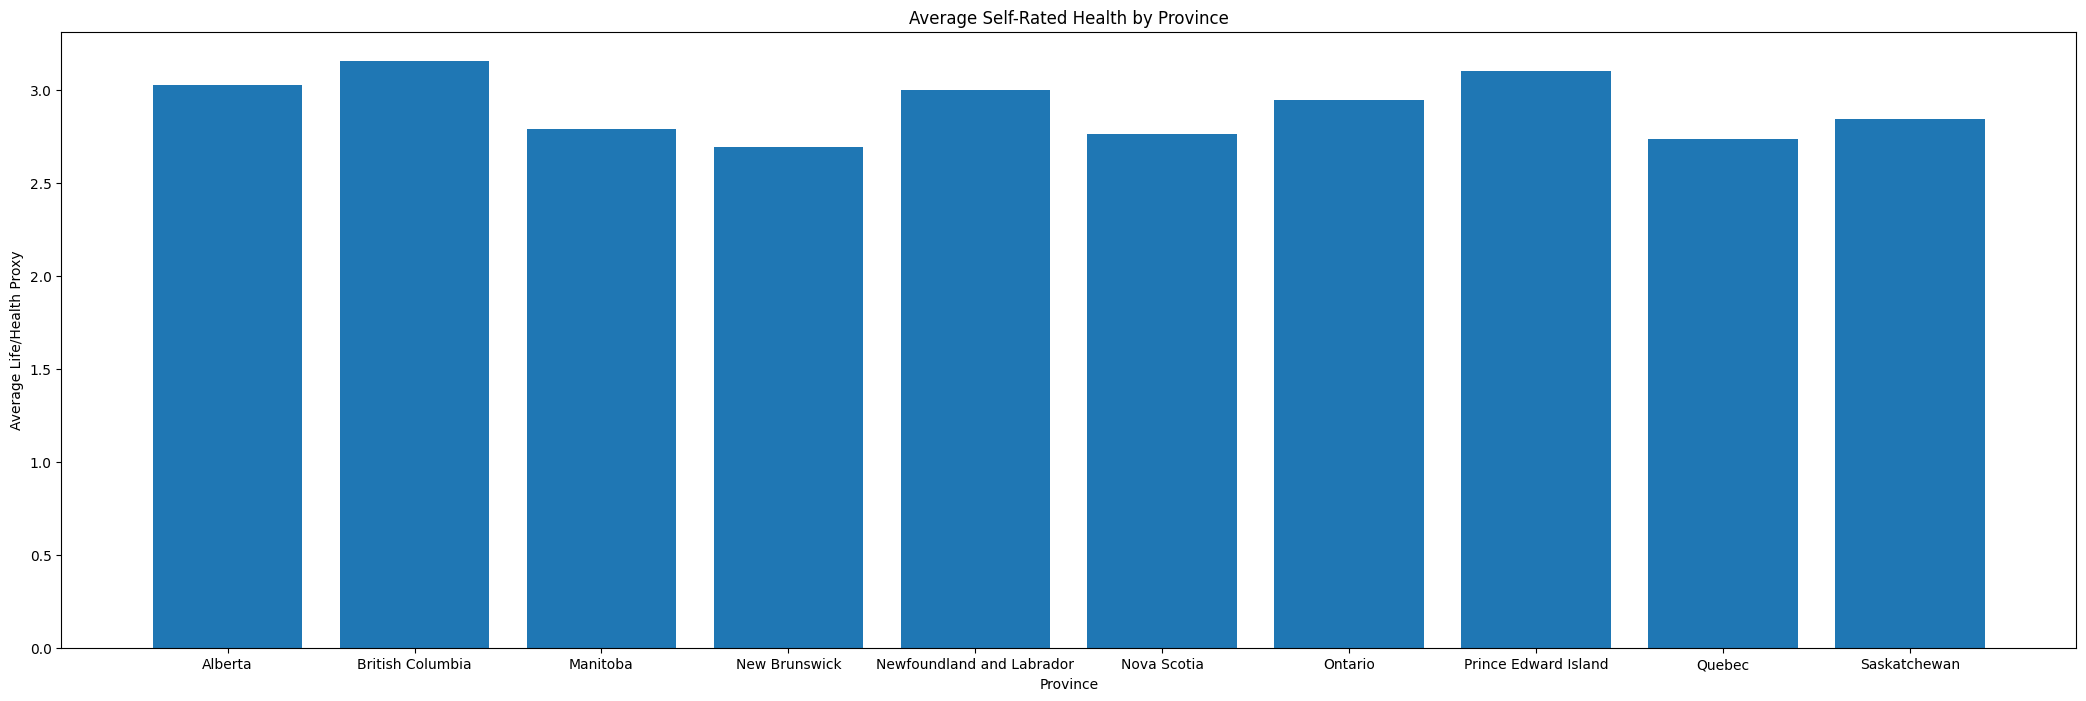

In [89]:
import matplotlib.pyplot as plt


health_map = {
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Very good': 4,
    'Excellent': 5
}

df['Health_Numeric'] = df['SelfRatedHealth'].map(health_map)
avg_health = df.groupby('Province')['Health_Numeric'].mean()

plt.figure(figsize=(26, 8))
plt.bar(avg_health.index, avg_health.values)
plt.xlabel('Province')
plt.ylabel('Average Life/Health Proxy')
plt.title('Average Self-Rated Health by Province')

plt.show()


C2)

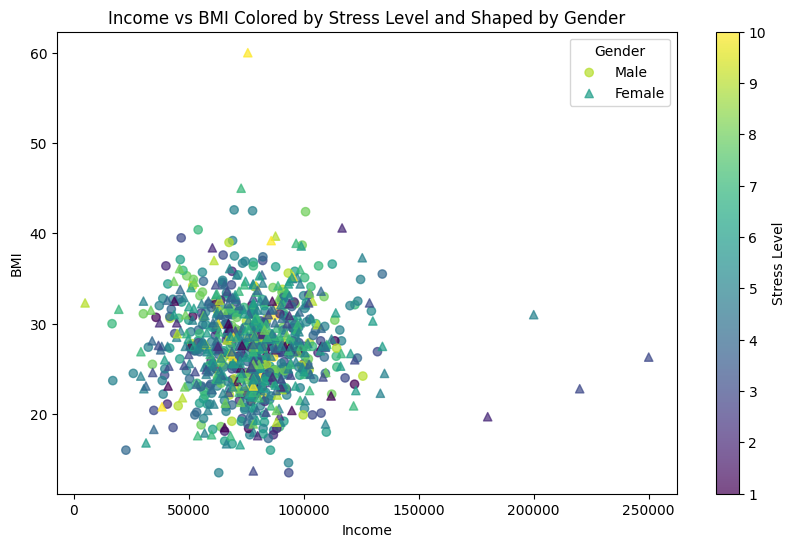

In [ ]:
plt.figure(figsize=(10, 6))

# Male points
male = df['Gender'] == 'Male'
plt.scatter(
    df.loc[male, 'Income'],
    df.loc[male, 'BMI'],
    c=df.loc[male, 'StressLevel'],
    cmap='viridis',
    marker='o',
    alpha=0.7,
    label='Male'
)

# Female points
female = df['Gender'] == 'Female'
sc = plt.scatter(
    df.loc[female, 'Income'],
    df.loc[female, 'BMI'],
    c=df.loc[female, 'StressLevel'],
    cmap='viridis',
    marker='^',
    alpha=0.7,
    label='Female'
)

# Colorbar (use one scatter object)
cbar = plt.colorbar(sc)
cbar.set_label('Stress Level')

# Labels and title
plt.xlabel('Income')
plt.ylabel('BMI')
plt.title('Income vs BMI Colored by Stress Level and Shaped by Gender')

# Legend for gender
plt.legend(title='Gender')

plt.show()



C3) 

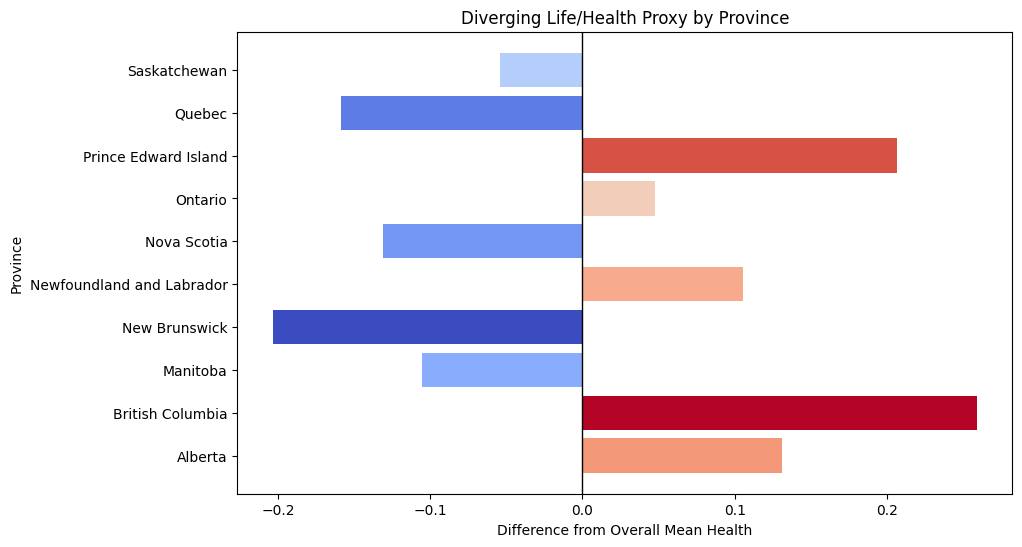

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors


overall_mean = df['Health_Numeric'].mean()


province_mean = df.groupby('Province')['Health_Numeric'].mean()


life_proxy_difference = province_mean - overall_mean

plt.figure(figsize=(10, 6))

norm = colors.TwoSlopeNorm(vcenter=0)
bar_colors = plt.cm.coolwarm(norm(life_proxy_difference.values))

plt.barh(
    life_proxy_difference.index,
    life_proxy_difference.values,
    color=bar_colors
)

plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Difference from Overall Mean Health')
plt.ylabel('Province')
plt.title('Diverging Life/Health Proxy by Province')

plt.show()

C4)

A diverging color scale makes it easy to see which provinces are above or below the average without having to read exact values. The horizontal layout keeps labels close to the data and avoids clutter, so the chart is quick to scan and easy to compare.

# Part D – Interpretation

D1)

The plot suggests there isn’t a strong relationship between income and BMI, since BMI values are fairly spread out across most income levels. Most observations cluster in the mid-income range with BMI around the mid-20s to low-30s, and higher incomes don’t consistently correspond to higher or lower BMI.

D2)

One limitation is the presence of income outliers, which can exaggerate the spread on the x-axis and make patterns harder to detect for the majority of observations. Additionally, any missing or inconsistently reported BMI or income values could bias the results if they are not missing at random.

In [94]:
df.to_csv('cleaned_data.csv', index=False)